<a href="https://colab.research.google.com/github/ellenbrackn/Fonte-de-informa-o-e-banco-de-dados/blob/main/analise_dados_temp_and_icecr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("raphaelmanayon/temperature-and-ice-cream-sales")

print("Path to dataset files:", path)

100%|██████████| 1.47k/1.47k [00:00<00:00, 3.36MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/raphaelmanayon/temperature-and-ice-cream-sales/versions/1


In [6]:
import pandas as pd
import os
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Assuming the CSV file is named 'Ice Cream Sales - temperatures.csv' inside the downloaded directory
csv_file_path = os.path.join(path, 'Ice Cream Sales - temperatures.csv')

df = pd.read_csv(csv_file_path)

# Display the first 5 rows of the DataFrame
display(df.head(10))

# Prepare the data for linear regression
X = df[['Temperature']]
y = df['Ice Cream Profits']

# Split the data into training and testing sets (optional but good practice)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a linear regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Print the coefficients and intercept
print(f"Intercept: {model.intercept_:.2f}")
print(f"Coefficient for Temperature: {model.coef_[0]:.2f}")

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

# Example prediction
example_temp = np.array([[75]]) # Example temperature
predicted_profit = model.predict(example_temp)
print(f"\nPredicted Ice Cream Profit for Temperature {example_temp[0][0]}°F: {predicted_profit[0]:.2f}")

,Temperature,Ice Cream Profits
0,39,13.17
1,40,11.88
2,41,18.82
3,42,18.65
4,43,17.02
5,43,15.88
6,44,19.07
7,44,19.57
8,45,21.62
9,45,22.34


Intercept: -33.66
Coefficient for Temperature: 1.19
Mean Squared Error: 5.29
R-squared: 0.98

Predicted Ice Cream Profit for Temperature 75°F: 55.60


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


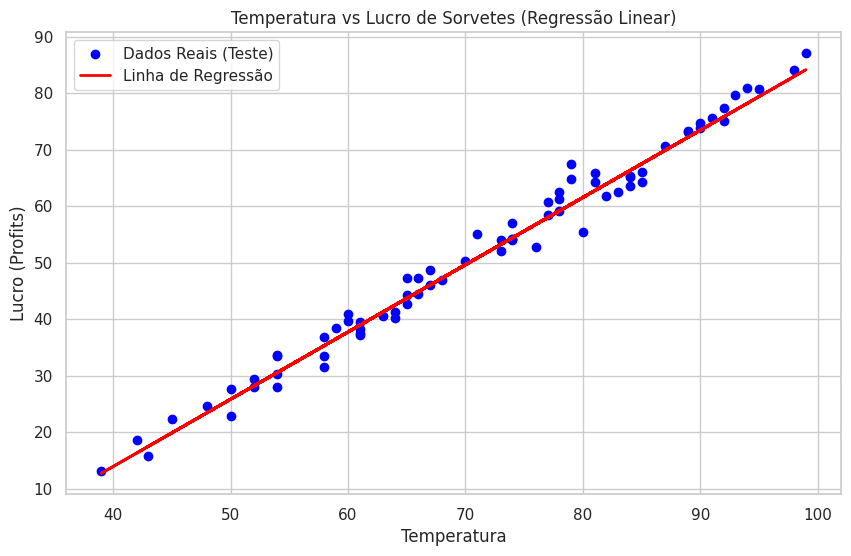

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar o estilo do gráfico
sns.set(style='whitegrid')
plt.figure(figsize=(10, 6))

# Plotar os pontos de dados reais (usando o conjunto de teste para clareza)
plt.scatter(X_test, y_test, color='blue', label='Dados Reais (Teste)')

# Plotar a linha de regressão
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Linha de Regressão')

# Adicionar títulos e legendas
plt.title('Temperatura vs Lucro de Sorvetes (Regressão Linear)')
plt.xlabel('Temperatura')
plt.ylabel('Lucro (Profits)')
plt.legend()
plt.show()

In [8]:
from sklearn.linear_model import LinearRegression

# Define the independent variable (X) and dependent variable (y)
X = df[['Temperature']]
y = df['Ice Cream Profits']

# Create a linear regression model
model = LinearRegression()

# Fit the model to the data
model.fit(X, y)

# Print the coefficient and intercept
print(f"Coefficient (Slope): {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")
print(f"Equação: {model.coef_[0]:.2f}*x + {model.intercept_:.2f}")

Coefficient (Slope): 1.19
Intercept: -33.70
Equação: 1.19*x + -33.70


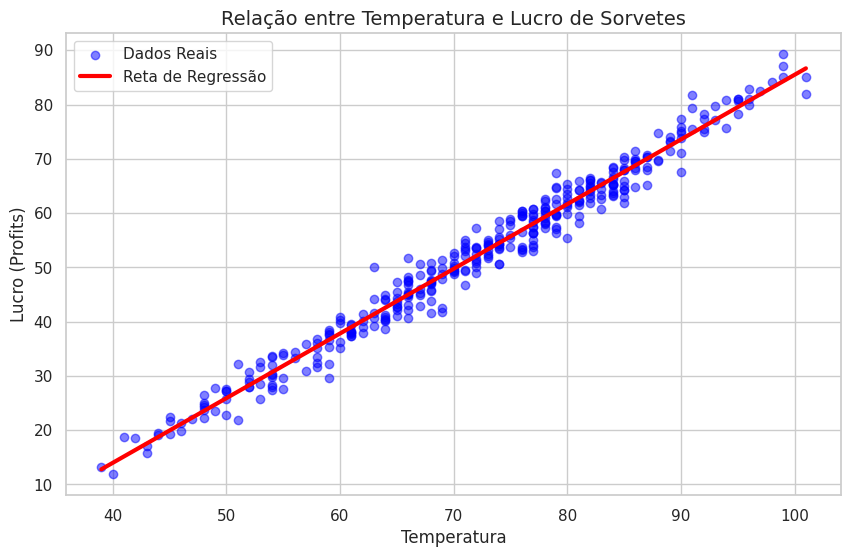

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar o estilo
sns.set(style='whitegrid')
plt.figure(figsize=(10, 6))

# Gráfico de dispersão dos dados reais
plt.scatter(df['Temperature'], df['Ice Cream Profits'], color='blue', alpha=0.5, label='Dados Reais')

# Reta de regressão baseada no modelo treinado
y_pred_line = model.predict(X)
plt.plot(df['Temperature'], y_pred_line, color='red', linewidth=3, label='Reta de Regressão')

# Títulos e legendas
plt.title('Relação entre Temperatura e Lucro de Sorvetes', fontsize=14)
plt.xlabel('Temperatura', fontsize=12)
plt.ylabel('Lucro (Profits)', fontsize=12)
plt.legend()
plt.show()